# 실험 4: Joint Diffusion — DDPM T=1000, 깨진 fake 걸러내기

In [36]:
import os
import subprocess

GPU_ID = None  # None이면 아래에서 가장 한가한 GPU를 자동 선택. 고정하려면 "0" / "1" / "2"처럼 지정


def pick_free_gpu():
    out = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=index,memory.used,utilization.gpu", "--format=csv,noheader,nounits"]
    ).decode()
    rows = [tuple(int(v) for v in line.split(",")) for line in out.strip().splitlines()]
    for idx, mem, util in rows:
        print(f"  GPU {idx}: memory {mem} MiB, util {util}%")
    return str(min(rows, key=lambda r: (r[1], r[2]))[0])


if GPU_ID is None:
    GPU_ID = pick_free_gpu()
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_ID
print("사용 GPU:", GPU_ID)
RUN_SEEDS = [0]  # seed 0만 먼저 확인 (전체는 list(range(5)))

  GPU 0: memory 16812 MiB, util 0%
  GPU 1: memory 8000 MiB, util 0%
  GPU 2: memory 0 MiB, util 0%
사용 GPU: 2


## 0. 라이브러리 & 공통 유틸 / 모델 정의

In [37]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
import sys
from pathlib import Path
_d = Path.cwd().resolve()
while not (_d / "models.py").exists():
    if _d.parent == _d:
        raise FileNotFoundError("상위 폴더 어디에도 models.py가 없습니다")
    _d = _d.parent
if str(_d) not in sys.path:
    sys.path.insert(0, str(_d))
print("공용 모듈 경로:", _d)

import os
import time
from collections import Counter

import numpy as np
import pandas as pd
import math

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from models import Unet, Classifier
from utils import (
    set_seed, DEVICE, SEEDS, EMA,
    evaluate_classifier, metrics_to_rows, append_result_rows,
)
from diffusion import GaussianDiffusion
from data import (
    build_imbalanced_group_split, crop_group, CachedDataset, CachedSubset,
    generate_fill_batch, FakeQualityFilter,
)

SEEDS = [s for s in SEEDS if s in RUN_SEEDS]

print("device:", DEVICE)
print("모델/유틸/데이터 모듈 로드 완료 (models.py, utils.py, diffusion.py, data.py)")


공용 모듈 경로: 7_diffusion_image_filter
device: cuda
모델/유틸/데이터 모듈 로드 완료 (models.py, utils.py, diffusion.py, data.py)


## 1. 데이터 생성: 불균형 데이터셋

In [39]:
image_size = 64
channels = 3
batch_size = 40
num_classes = 3

data_root = os.environ.get("DATA_ROOT", "../../data/AM_image_data_3split")  # 원본 213x460 (한 장을 3조각 낸 k0/k1/k2) → 아래 transform에서 64x64로 resize

RESUME = False  # 다시 실행하면 기존 결과 CSV를 지우고 새로 만든다
RESULTS_CSV = "exp4_joint_diffusion_step10.csv"
if not RESUME and os.path.exists(RESULTS_CSV):
    os.remove(RESULTS_CSV)

CLASS_NAMES = ["Normal", "Underfill_50FR", "Underfill_Fan"]  # ImageFolder는 폴더명 알파벳순으로 라벨을 매김 (Normal=0, Underfill_50FR=1, Underfill_Fan=2)

train_counts = {0: 800, 1: 80, 2: 80}
test_counts = {0: 100, 1: 100, 2: 100}

transform = T.Compose([
    T.Resize((image_size, image_size)),
    T.ToTensor(),
    T.Lambda(lambda t: (t * 2) - 1),  # [0,1] -> [-1,1]
])

full_dataset = ImageFolder(root=data_root, transform=transform)
assert full_dataset.classes == CLASS_NAMES, full_dataset.classes

full_cached = CachedDataset(full_dataset)


def set_split(seed):
    global train_indices, test_indices, train_dataset, test_dataset
    global train_loader, test_loader, train_labels, test_labels
    train_indices, test_indices = build_imbalanced_group_split(full_dataset, train_counts, test_counts, seed=seed)
    leaked = ({crop_group(full_dataset.samples[i][0]) for i in train_indices}
              & {crop_group(full_dataset.samples[i][0]) for i in test_indices})
    assert not leaked, f"같은 원본이 train/test에 모두 있음: {sorted(leaked)[:5]}"

    train_dataset = CachedSubset(full_cached, train_indices)
    test_dataset = CachedSubset(full_cached, test_indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True,
                               pin_memory=(DEVICE == "cuda"))
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                              pin_memory=(DEVICE == "cuda"))

    train_labels = [full_dataset.samples[i][1] for i in train_indices]
    test_labels = [full_dataset.samples[i][1] for i in test_indices]


set_split(0)  # 미리보기/학습량 기준(BASELINE_STEPS) 계산용 초기 분할
print("SEEDS:", SEEDS)
print("Train label distribution:", Counter(train_labels))
print("Test  label distribution:", Counter(test_labels))


SEEDS: [0]
Train label distribution: Counter({0: 800, 1: 80, 2: 80})
Test  label distribution: Counter({0: 100, 1: 100, 2: 100})


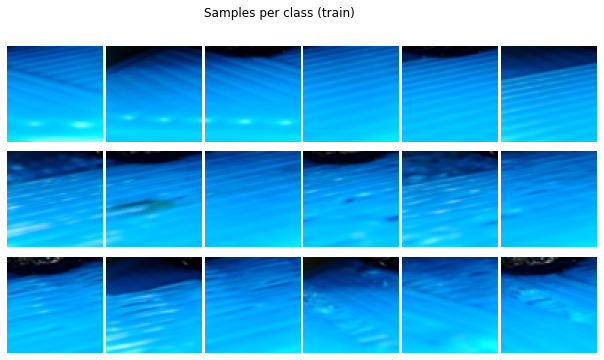

In [40]:
def denorm(x):
    return (x + 1) / 2

W, L, R = 9, 0.13, 0.99
cell = W * (R - L) / 6
H = num_classes * cell + 0.6
fig, axes = plt.subplots(num_classes, 6, figsize=(W, H))
for cls in range(num_classes):
    idxs = [i for i, y in enumerate(train_labels) if y == cls][:6]
    for j, idx in enumerate(idxs):
        img, _ = train_dataset[idx]
        axes[cls, j].imshow(denorm(img).permute(1, 2, 0).numpy())
        axes[cls, j].axis("off")
    axes[cls, 0].text(-0.05, 0.5, CLASS_NAMES[cls], transform=axes[cls, 0].transAxes,
                      ha="right", va="center", fontsize=8)
plt.suptitle("Samples per class (train)")
plt.subplots_adjust(left=L, right=R, bottom=0.05 / H, top=1 - 0.55 / H, wspace=0.03, hspace=0.03)
plt.show()

## 2. 설정 (diffusion 스케줄 / 분류기 / joint)

In [41]:
timesteps = 1000
ddpm = GaussianDiffusion(timesteps=timesteps, image_size=image_size, channels=channels)
FILL_STEPS = 10

FILTER_FAR_Q = 0.95   # 가장 가까운 실제 이미지까지 거리가 실제끼리 NN 거리의 이 분위수(1.0 = 최댓값)를 넘으면 제외
FILTER_OVERGEN = 2.0   # 한 라운드에 모자란 수의 몇 배를 생성할지 (걸러질 것을 감안. 모자라면 다 찰 때까지 반복 생성)


CLASSIFIER_EPOCHS_REF = 100
CLASSIFIER_LR = 2e-4
CLASSIFIER_BETAS = (0.5, 0.9)
BASELINE_STEPS = len(train_loader) * CLASSIFIER_EPOCHS_REF
print(f"분류기 학습 기준 step 수 (BASELINE_STEPS) = {len(train_loader)} batches/epoch "
      f"x {CLASSIFIER_EPOCHS_REF} epochs = {BASELINE_STEPS}")

PRETRAIN_EPOCHS = 400
JOINT_EPOCHS = CLASSIFIER_EPOCHS_REF
EMA_DECAY = 0.999

SHARED_LAMBDA_MAX = 0.001
SHARED_STEPS = FILL_STEPS  # 협력 항 샘플링 스텝 수 (fake 생성과 같은 10스텝)


분류기 학습 기준 step 수 (BASELINE_STEPS) = 24 batches/epoch x 100 epochs = 2400


## 3. 사전학습 & Joint 학습 함수

In [42]:
def build_quality_filter(minority_classes=(1, 2)):
    xs, ys = zip(*[train_dataset[i] for i in range(len(train_dataset))])
    real_x = torch.stack(xs).to(DEVICE)
    real_y = torch.as_tensor(ys, device=DEVICE)
    qf = FakeQualityFilter(real_x, real_y, minority_classes, far_q=FILTER_FAR_Q)
    for c in minority_classes:
        print(f"  [Filter] class {c}: 거리 기준 {qf.t_far[c]:.3f} (실제 {int((real_y == c).sum())}장 기준)")
    return qf


def generate_filtered_fill_batch(model, real_y, qf, minority_classes=(1, 2)):
    device = real_y.device
    n0 = (real_y == 0).sum().item()
    need = {c: max(0, n0 - (real_y == c).sum().item()) for c in minority_classes}
    need = {c: n for c, n in need.items() if n > 0}
    if not need:
        return None, None, 0, 0

    kept = {c: [] for c in need}        # 필터를 통과한 이미지
    n_kept = {c: 0 for c in need}
    n_gen, rounds = 0, 0
    while True:
        lack = {c: need[c] - n_kept[c] for c in need if n_kept[c] < need[c]}
        if not lack:
            break
        y_gen = torch.cat([torch.full((math.ceil(n * FILTER_OVERGEN),), c, dtype=torch.long, device=device)
                           for c, n in lack.items()])
        x_gen = ddpm.sample_ddpm_respaced(model, y_gen, device, steps=FILL_STEPS)
        n_gen += y_gen.numel()
        rounds += 1
        for c in lack:
            xc = x_gen[y_gen == c]
            good = xc[qf.accept(xc, c)]
            kept[c].append(good)
            n_kept[c] += good.size(0)
        if rounds % 50 == 0:  # 통과율이 너무 낮아 오래 걸릴 때 알 수 있게
            tqdm.write(f"  [Filter] {rounds}라운드째 생성 중: 통과 {n_kept} / 필요 {need} (FILTER_FAR_Q를 올려야 할 수 있음)")

    xs, ys = [], []
    for c, n in need.items():
        xs.append(torch.cat(kept[c])[:n])
        ys.append(torch.full((n,), c, dtype=torch.long, device=device))
    return torch.cat(xs), torch.cat(ys), n_gen, sum(n_kept.values())


def pretrain_diffusion(seed, epochs=None):
    epochs = epochs or PRETRAIN_EPOCHS
    set_seed(seed)
    device = DEVICE

    diffusion = Unet(dim=32, channels=channels, num_classes=num_classes).to(device)
    opt_g = torch.optim.Adam(diffusion.parameters(), lr=2e-4)
    diffusion_loss_fn = nn.MSELoss()
    ema = EMA(diffusion, decay=EMA_DECAY)
    t0 = time.time()

    pbar = tqdm(range(epochs), desc=f"[Pretrain seed{seed}]")
    for epoch in pbar:
        diffusion.train()
        epoch_losses = []
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            t = torch.randint(0, timesteps, (x.size(0),), device=device)
            noise = torch.randn_like(x)
            x_noisy = ddpm.q_sample(x, t, noise)

            pred_noise = diffusion(x_noisy, t, y)
            loss = diffusion_loss_fn(pred_noise, noise)

            opt_g.zero_grad()
            loss.backward()
            opt_g.step()
            ema.update(diffusion)

            epoch_losses.append(loss.item())

        pbar.set_postfix(diff=f"{np.mean(epoch_losses):.4f}")
        if (epoch + 1) % 100 == 0 or epoch == epochs - 1:
            tqdm.write(f"[Pretrain seed{seed}] Epoch {epoch+1}/{epochs} Diff={np.mean(epoch_losses):.4f} "
                       f"elapsed={time.time()-t0:.1f}s")

    return diffusion, ema


PRETRAINED_PATH = "checkpoints/exp4_pretrained_seed{seed}.pt"  # 사전학습은 fill 스텝 수와 무관
PRETRAINED_EMA_PATH = "checkpoints/exp4_pretrained_ema_seed{seed}.pt"
os.makedirs("checkpoints", exist_ok=True)


def load_or_pretrain_diffusion(seed):
    path, ema_path = PRETRAINED_PATH.format(seed=seed), PRETRAINED_EMA_PATH.format(seed=seed)
    if os.path.exists(path) and os.path.exists(ema_path):
        diffusion = Unet(dim=32, channels=channels, num_classes=num_classes).to(DEVICE)
        diffusion.load_state_dict(torch.load(path, map_location=DEVICE))
        ema = EMA(diffusion, decay=EMA_DECAY)
        ema.model.load_state_dict(torch.load(ema_path, map_location=DEVICE))
        ema.num_updates = PRETRAIN_EPOCHS * len(train_loader)
        print(f"[Pretrain seed{seed}] 사전학습 건너뜀: {path}, {ema_path} 로드")
        return diffusion, ema
    diffusion, ema = pretrain_diffusion(seed)
    torch.save(diffusion.state_dict(), path)
    torch.save(ema.model.state_dict(), ema_path)
    return diffusion, ema


PREVIEW_EVERY = 10  # joint 학습 중 이 epoch마다 EMA 모델 샘플을 그려 본다


@torch.no_grad()
def sample_filtered_rows(model, qf, n_per_class=6, minority_classes=(1, 2), noise_seed=1234):
    rows, stats = [], {}
    with torch.random.fork_rng(devices=[torch.device(DEVICE)] if DEVICE == "cuda" else []):
        torch.manual_seed(noise_seed)
        for c in range(num_classes):
            y_c = torch.full((n_per_class,), c, dtype=torch.long, device=DEVICE)
            if c not in minority_classes:
                rows.append(ddpm.sample_ddpm_respaced(model, y_c, DEVICE, steps=FILL_STEPS).cpu())
                continue
            kept, n_kept, n_gen = [], 0, 0
            while n_kept < n_per_class:
                x = ddpm.sample_ddpm_respaced(model, y_c, DEVICE, steps=FILL_STEPS)
                good = x[qf.accept(x, c)]
                kept.append(good.cpu())
                n_kept += good.size(0)
                n_gen += n_per_class
            rows.append(torch.cat(kept)[:n_per_class])
            stats[c] = (n_kept, n_gen)
    return torch.cat(rows), stats


def preview_samples(model, qf, seed, epoch, n_per_class=6):
    x_vis, stats = sample_filtered_rows(model, qf, n_per_class)
    grid = make_grid(((x_vis + 1) / 2).clamp(0, 1), nrow=n_per_class, padding=2)
    plt.figure(figsize=(9, 1.5 * num_classes + 0.5))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    pass_txt = ", ".join(f"class {c} kept {k}/{g}" for c, (k, g) in stats.items())
    plt.title(f"seed {seed}, joint epoch {epoch}: EMA samples ({FILL_STEPS} steps, filtered) - class 0 / 1 / 2 (top to bottom)\n{pass_txt}", fontsize=9)
    plt.tight_layout()
    out_dir = f"exp4_images/exp4_images_seed{seed}"   # seed마다 폴더를 따로 둔다
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(f"{out_dir}/epoch{epoch:03d}.png", dpi=110)
    plt.show()


def run_joint_diffusion(seed, diffusion, ema, qf, minority_classes=(1, 2)):
    set_seed(seed)
    device = DEVICE

    classifier = Classifier(num_classes=num_classes, img_channels=channels, image_size=image_size).to(device)
    opt_g = torch.optim.Adam(diffusion.parameters(), lr=2e-4)
    opt_c = torch.optim.Adam(classifier.parameters(), lr=CLASSIFIER_LR, betas=CLASSIFIER_BETAS)
    diffusion_loss_fn = nn.MSELoss()
    cls_loss_fn = nn.CrossEntropyLoss()
    t0 = time.time()

    pbar = tqdm(range(JOINT_EPOCHS), desc=f"[Joint seed{seed}]")
    for epoch in pbar:
        w_shared = epoch / max(1, JOINT_EPOCHS - 1)
        lam_shared = SHARED_LAMBDA_MAX * w_shared   # 협력 항 λ: 0 → SHARED_LAMBDA_MAX

        diffusion.train()
        classifier.train()
        ep_diff, ep_shared, ep_lam, ep_cls = [], [], [], []
        ep_gratio, ep_gunit = [], []   # gradient 크기 비교용 (아래 협력 항 블록에서 채운다)
        ep_cpass = [0, 0]              # 협력 항 이미지의 필터 통과 수 / 생성 수
        n_gen, n_ok = 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            x_fake, y_fake, g, ok = generate_filtered_fill_batch(ema.model, y, qf, minority_classes)
            n_gen += g
            n_ok += ok

            t = torch.randint(0, timesteps, (x.size(0),), device=device)
            noise = torch.randn_like(x)
            x_noisy = ddpm.q_sample(x, t, noise)
            loss_diff = diffusion_loss_fn(diffusion(x_noisy, t, y), noise)

            opt_g.zero_grad()
            loss_diff.backward()
            ep_diff.append(loss_diff.item())

            if lam_shared > 0 and x_fake is not None:
                y_shared = y_fake
                x_shared = ddpm.sample_ddpm_respaced_grad(diffusion, y_shared, device, steps=SHARED_STEPS)
                with torch.no_grad():  # 필터 통과 여부 (gradient 없음)
                    ok_shared = torch.zeros(y_shared.size(0), dtype=torch.bool, device=device)
                    for c in minority_classes:
                        m_c = y_shared == c
                        if m_c.any():
                            ok_shared[m_c] = qf.accept(x_shared[m_c].detach(), c)
                ep_cpass[0] += int(ok_shared.sum())
                ep_cpass[1] += ok_shared.numel()
                loss_shared = cls_loss_fn(classifier(x_shared[ok_shared]), y_shared[ok_shared]) if ok_shared.any() else None

                if loss_shared is not None and torch.isfinite(loss_shared):
                    g_diff = [p.grad.detach().clone() if p.grad is not None else torch.zeros_like(p)
                              for p in diffusion.parameters()]
                    (lam_shared * loss_shared).backward()
                    with torch.no_grad():
                        n_diff = torch.sqrt(sum((g ** 2).sum() for g in g_diff))
                        n_coop = torch.sqrt(sum(((p.grad - g) ** 2).sum() if p.grad is not None else (g * 0).sum()
                                                for p, g in zip(diffusion.parameters(), g_diff)))
                        ep_gratio.append((n_coop / (n_diff + 1e-12)).item())                     # |λ∇협력| / |∇diff|
                        ep_gunit.append((n_coop / lam_shared / (n_diff + 1e-12)).item())          # λ=1일 때의 비율
                    ep_shared.append(loss_shared.item())
                    ep_lam.append(lam_shared)

            if x_fake is not None:
                x_batch, y_batch = torch.cat([x, x_fake]), torch.cat([y, y_fake])
            else:
                x_batch, y_batch = x, y
            loss_cls = cls_loss_fn(classifier(x_batch), y_batch)

            opt_c.zero_grad()
            loss_cls.backward()
            opt_g.step()
            ema.update(diffusion)
            opt_c.step()
            ep_cls.append(loss_cls.item())

        mean = lambda v: float(np.mean(v)) if v else float("nan")
        acc = n_ok / max(1, n_gen)
        pbar.set_postfix(diff=f"{mean(ep_diff):.4f}", cls=f"{mean(ep_cls):.4f}", lam=f"{mean(ep_lam):.4f}", keep=f"{acc:.2f}")
        if (epoch + 1) % 10 == 0 or epoch == JOINT_EPOCHS - 1:
            tqdm.write(f"[Joint seed{seed}] Epoch {epoch+1}/{JOINT_EPOCHS} "
                       f"Diff={mean(ep_diff):.4f} Shared(CE)={mean(ep_shared):.4f} λ={mean(ep_lam):.4f} "
                       f"w={w_shared:.3f} Cls={mean(ep_cls):.4f} fake 통과율={acc:.2f} 협력항 통과율={ep_cpass[0] / max(1, ep_cpass[1]):.2f} elapsed={time.time()-t0:.1f}s")
            if ep_gunit:
                u = mean(ep_gunit)
                tqdm.write(f"    [grad 비교] |λ∇협력|/|∇diff| = {mean(ep_gratio):.3f} (λ=1이면 {u:.1f}) "
                           f"→ 비율 0.1~1로 맞추려면 λ ≈ {0.1 / u:.5f} ~ {1.0 / u:.5f}")
            preview_samples(ema.model, qf, seed, epoch + 1)

    return diffusion, ema, classifier


## 실험 4: Joint 학습 & 평가


===== Joint Diffusion (DDPM T=1000, fill 10스텝) | Seed 0 =====
[Pretrain seed0] 사전학습 건너뜀: exp3_ddpm1000_diffusion_pretrained_seed0.pt, exp3_ddpm1000_diffusion_pretrained_ema_seed0.pt 로드
  [Filter] class 1: 거리 기준 3.057 (실제 80장 기준)
  [Filter] class 2: 거리 기준 4.363 (실제 80장 기준)


[Joint seed0]:   9%|▉         | 9/100 [07:58<1:16:05, 50.17s/it, cls=0.6269, diff=0.0045, keep=0.39, lam=0.0001]

[Joint seed0] Epoch 10/100 Diff=0.0045 Shared(CE)=0.2356 λ=0.0001 w=0.091 Cls=0.6269 fake 통과율=0.39 협력항 통과율=0.16 elapsed=478.6s
    [grad 비교] |λ∇협력|/|∇diff| = 0.274 (λ=1이면 3016.7) → 비율 0.1~1로 맞추려면 λ ≈ 0.00003 ~ 0.00033


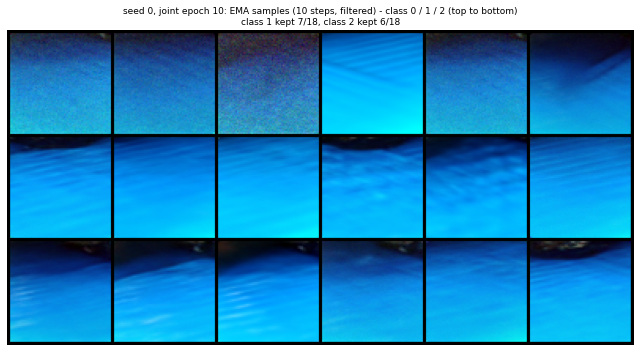

[Joint seed0]:  19%|█▉        | 19/100 [15:52<1:05:29, 48.51s/it, cls=0.3180, diff=0.0052, keep=0.36, lam=0.0002]

[Joint seed0] Epoch 20/100 Diff=0.0052 Shared(CE)=0.1464 λ=0.0002 w=0.192 Cls=0.3180 fake 통과율=0.36 협력항 통과율=0.15 elapsed=952.9s
    [grad 비교] |λ∇협력|/|∇diff| = 1.112 (λ=1이면 5796.3) → 비율 0.1~1로 맞추려면 λ ≈ 0.00002 ~ 0.00017


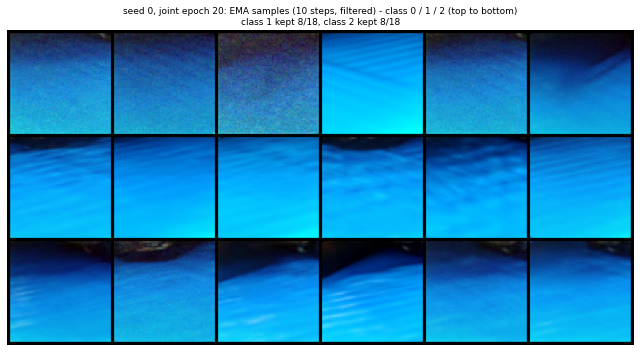

[Joint seed0]:  29%|██▉       | 29/100 [25:04<1:09:57, 59.12s/it, cls=0.2858, diff=0.0037, keep=0.33, lam=0.0003]

[Joint seed0] Epoch 30/100 Diff=0.0037 Shared(CE)=0.0124 λ=0.0003 w=0.293 Cls=0.2858 fake 통과율=0.33 협력항 통과율=0.15 elapsed=1504.1s
    [grad 비교] |λ∇협력|/|∇diff| = 0.111 (λ=1이면 378.6) → 비율 0.1~1로 맞추려면 λ ≈ 0.00026 ~ 0.00264


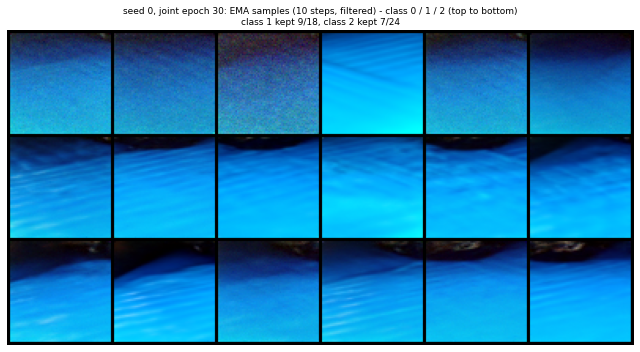

[Joint seed0]:  39%|███▉      | 39/100 [34:33<56:23, 55.47s/it, cls=0.1901, diff=0.0036, keep=0.34, lam=0.0004]  

[Joint seed0] Epoch 40/100 Diff=0.0036 Shared(CE)=0.0257 λ=0.0004 w=0.394 Cls=0.1901 fake 통과율=0.34 협력항 통과율=0.30 elapsed=2073.6s
    [grad 비교] |λ∇협력|/|∇diff| = 0.176 (λ=1이면 445.8) → 비율 0.1~1로 맞추려면 λ ≈ 0.00022 ~ 0.00224


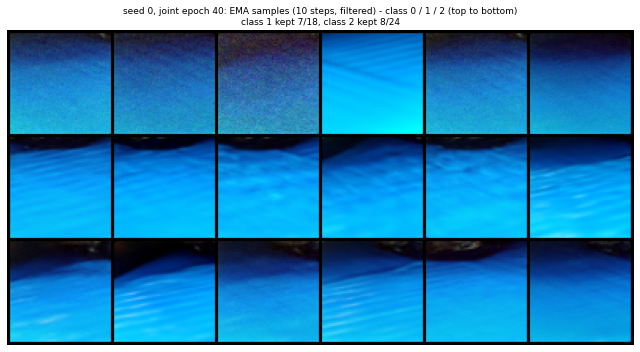

[Joint seed0]:  49%|████▉     | 49/100 [43:21<42:25, 49.90s/it, cls=0.1311, diff=0.0038, keep=0.34, lam=0.0005]

[Joint seed0] Epoch 50/100 Diff=0.0038 Shared(CE)=0.0257 λ=0.0005 w=0.495 Cls=0.1311 fake 통과율=0.34 협력항 통과율=0.19 elapsed=2601.1s
    [grad 비교] |λ∇협력|/|∇diff| = 0.178 (λ=1이면 360.5) → 비율 0.1~1로 맞추려면 λ ≈ 0.00028 ~ 0.00277


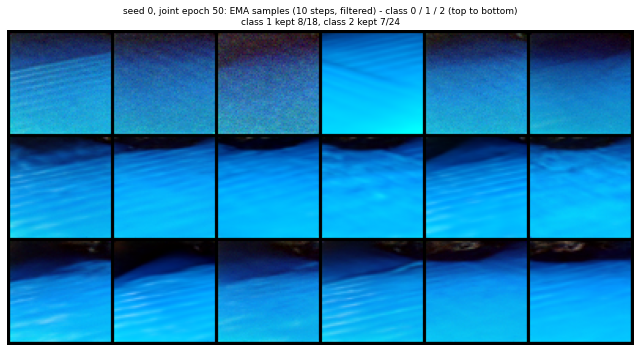

[Joint seed0]:  59%|█████▉    | 59/100 [53:04<40:13, 58.86s/it, cls=0.1015, diff=0.0041, keep=0.32, lam=0.0006]

[Joint seed0] Epoch 60/100 Diff=0.0041 Shared(CE)=0.0196 λ=0.0006 w=0.596 Cls=0.1015 fake 통과율=0.32 협력항 통과율=0.12 elapsed=3184.4s
    [grad 비교] |λ∇협력|/|∇diff| = 0.307 (λ=1이면 515.8) → 비율 0.1~1로 맞추려면 λ ≈ 0.00019 ~ 0.00194


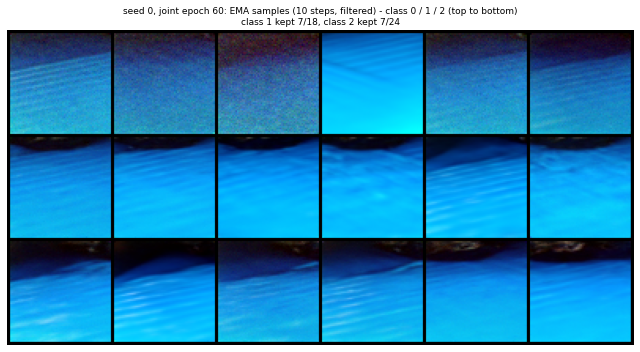

[Joint seed0]:  69%|██████▉   | 69/100 [1:03:17<32:40, 63.25s/it, cls=0.0745, diff=0.0033, keep=0.29, lam=0.0007]

[Joint seed0] Epoch 70/100 Diff=0.0033 Shared(CE)=0.0011 λ=0.0007 w=0.697 Cls=0.0745 fake 통과율=0.29 협력항 통과율=0.21 elapsed=3797.1s
    [grad 비교] |λ∇협력|/|∇diff| = 0.056 (λ=1이면 79.7) → 비율 0.1~1로 맞추려면 λ ≈ 0.00125 ~ 0.01254


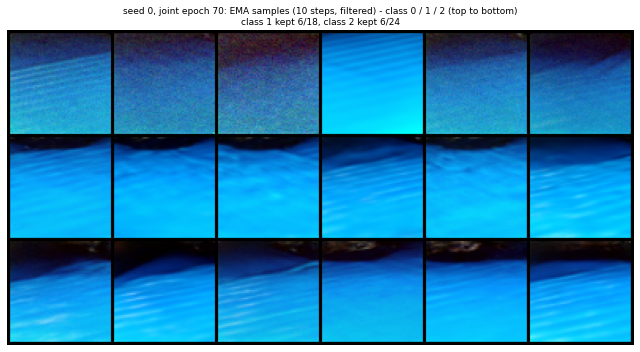

[Joint seed0]:  79%|███████▉  | 79/100 [1:13:35<21:53, 62.53s/it, cls=0.0802, diff=0.0032, keep=0.30, lam=0.0008]

[Joint seed0] Epoch 80/100 Diff=0.0032 Shared(CE)=0.0582 λ=0.0008 w=0.798 Cls=0.0802 fake 통과율=0.30 협력항 통과율=0.15 elapsed=4415.8s
    [grad 비교] |λ∇협력|/|∇diff| = 0.597 (λ=1이면 748.7) → 비율 0.1~1로 맞추려면 λ ≈ 0.00013 ~ 0.00134


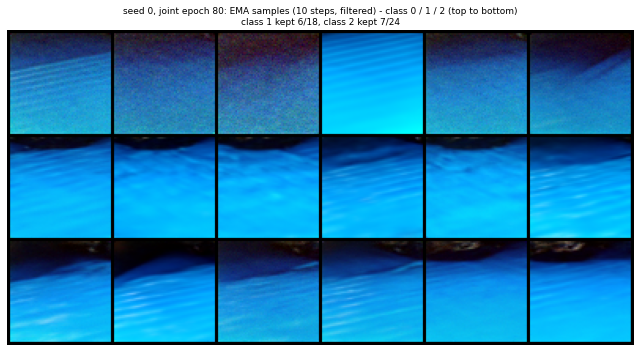

[Joint seed0]:  89%|████████▉ | 89/100 [1:25:25<13:31, 73.79s/it, cls=0.0559, diff=0.0040, keep=0.21, lam=0.0009]

[Joint seed0] Epoch 90/100 Diff=0.0040 Shared(CE)=0.0017 λ=0.0009 w=0.899 Cls=0.0559 fake 통과율=0.21 협력항 통과율=0.14 elapsed=5125.9s
    [grad 비교] |λ∇협력|/|∇diff| = 0.097 (λ=1이면 108.2) → 비율 0.1~1로 맞추려면 λ ≈ 0.00092 ~ 0.00925


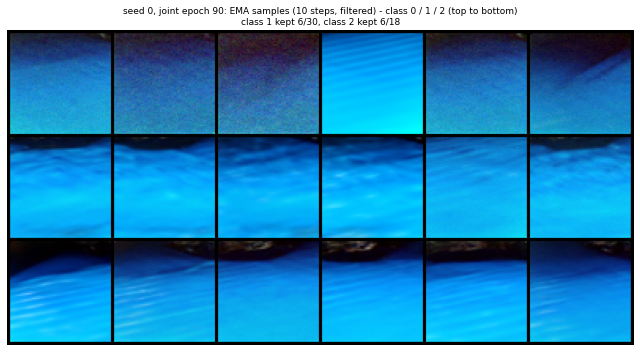

[Joint seed0]:  99%|█████████▉| 99/100 [1:41:11<01:36, 96.04s/it, cls=0.0469, diff=0.0033, keep=0.17, lam=0.0010]

[Joint seed0] Epoch 100/100 Diff=0.0033 Shared(CE)=0.0020 λ=0.0010 w=1.000 Cls=0.0469 fake 통과율=0.17 협력항 통과율=0.35 elapsed=6071.4s
    [grad 비교] |λ∇협력|/|∇diff| = 0.052 (λ=1이면 51.6) → 비율 0.1~1로 맞추려면 λ ≈ 0.00194 ~ 0.01937


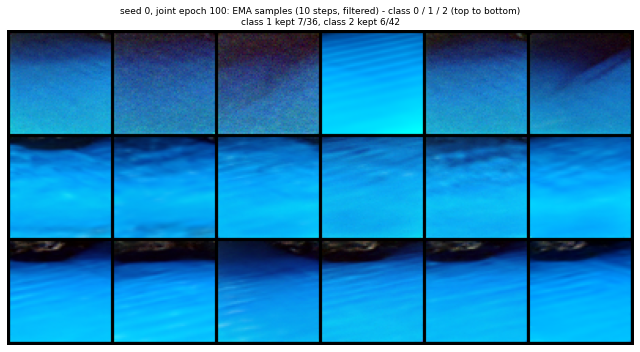

[Joint seed0]: 100%|██████████| 100/100 [1:41:14<00:00, 60.75s/it, cls=0.0469, diff=0.0033, keep=0.17, lam=0.0010]

[Exp3 seed0] 총 소요 시간: 6075.0초
===== Evaluation =====
Accuracy        : 0.7900
Precision(macro): 0.8318
Recall(macro)   : 0.7900
F1(macro)       : 0.7878

Per-class:
Class Normal | P:0.646 R:0.950 F1:0.769 N:100
Class Underfill_50FR | P:0.905 R:0.570 F1:0.699 N:100
Class Underfill_Fan | P:0.944 R:0.850 F1:0.895 N:100

Confusion Matrix:
 [[95  2  3]
 [41 57  2]
 [11  4 85]]


,method,seed,class,precision,recall,f1,support,accuracy
0,3_joint_diffusion_ddpm1000_step10_filtered,0,0,0.646259,0.95,0.769231,100,0.79
1,3_joint_diffusion_ddpm1000_step10_filtered,0,1,0.904762,0.57,0.699387,100,0.79
2,3_joint_diffusion_ddpm1000_step10_filtered,0,2,0.944444,0.85,0.894737,100,0.79
3,3_joint_diffusion_ddpm1000_step10_filtered,0,macro,0.831822,0.79,0.787785,300,0.79



===== seed 1개 평균 ± 표준편차 (CSV 전체) =====


n_seeds  \
method                                     class                     
3_joint_diffusion_ddpm1000_step10_filtered Normal                1   
                                           Underfill_50FR        1   
                                           Underfill_Fan         1   
                                           macro                 1   

                                                             precision  \
method                                     class                         
3_joint_diffusion_ddpm1000_step10_filtered Normal          0.646 ± nan   
                                           Underfill_50FR  0.905 ± nan   
                                           Underfill_Fan   0.944 ± nan   
                                           macro           0.832 ± nan   

                                                                recall  \
method                                     class                         
3_joint_diffusion_ddpm1000_step10_filtered Normal          0.950 ± nan   
                                           Underfill_50FR  0.570 ± nan   
                                           Underfill_Fan   0.850 ± nan   
                                           macro           0.790 ± nan   

                                                                    f1  \
method                                     class                         
3_joint_diffusion_ddpm1000_step10_filtered Normal          0.769 ± nan   
                                           Underfill_50FR  0.699 ± nan   
                                           Underfill_Fan   0.895 ± nan   
                                           macro           0.788 ± nan   

                                                              accuracy  
method                                     class                        
3_joint_diffusion_ddpm1000_step10_filtered Normal          0.790 ± nan  
                                           Underfill_50FR  0.790 ± nan  
                                           Underfill_Fan   0.790 ± nan  
                                           macro           0.790 ± nan

In [43]:
METHOD = f"4_joint_diffusion_ddpm1000_step{FILL_STEPS}_filtered"
joint_rows = []
joint_models = {}  # 미리보기용 EMA 모델 (joint 후)

done = set()
if RESUME and os.path.exists(RESULTS_CSV) and os.path.getsize(RESULTS_CSV) > 0:
    _prev = pd.read_csv(RESULTS_CSV)
    done = set(zip(_prev["method"], _prev["seed"]))
    print(f"[Resume] 이미 끝난 (method, seed) {len(done)}개는 건너뜀")

for seed in SEEDS:
    if (METHOD, seed) in done:
        print(f"[Exp4 seed{seed}] 결과 있음 → 건너뜀")
        continue
    set_split(seed)  # seed마다 train/test 분할을 새로 뽑는다 (학습 전에 반드시 먼저)
    print(f"\n===== Joint Diffusion (DDPM T={timesteps}, fill {FILL_STEPS}스텝) | Seed {seed} =====")
    t0 = time.time()
    diffusion, ema = load_or_pretrain_diffusion(seed)
    qf = build_quality_filter()
    diffusion, ema, classifier = run_joint_diffusion(seed, diffusion, ema, qf)
    print(f"[Exp4 seed{seed}] 총 소요 시간: {time.time()-t0:.1f}초")

    joint_models[seed] = ema.model

    metrics = evaluate_classifier(classifier, test_loader, DEVICE, num_classes, CLASS_NAMES)
    rows = metrics_to_rows(metrics, seed, METHOD)
    joint_rows.extend(rows)
    append_result_rows(rows, RESULTS_CSV)

df_joint = pd.DataFrame(joint_rows)


def seed_summary(df):
    cols = ["precision", "recall", "f1", "accuracy"]
    d = df.assign(**{"class": df["class"].astype(str).replace({str(i): n for i, n in enumerate(CLASS_NAMES)})})
    g = d.groupby(["method", "class"], sort=False)[cols]
    out = g.mean().applymap("{:.3f}".format) + " ± " + g.std(ddof=1).applymap("{:.3f}".format)
    out.insert(0, "n_seeds", g.size())
    return out


display(df_joint)
df_all_runs = pd.read_csv(RESULTS_CSV).drop_duplicates(subset=["method", "seed", "class"], keep="last")
print(f"\n===== seed {df_all_runs['seed'].nunique()}개 평균 ± 표준편차 (CSV 전체) =====")
seed_summary(df_all_runs)


  [Filter] class 1: 거리 기준 3.057 (실제 80장 기준)
  [Filter] class 2: 거리 기준 4.363 (실제 80장 기준)


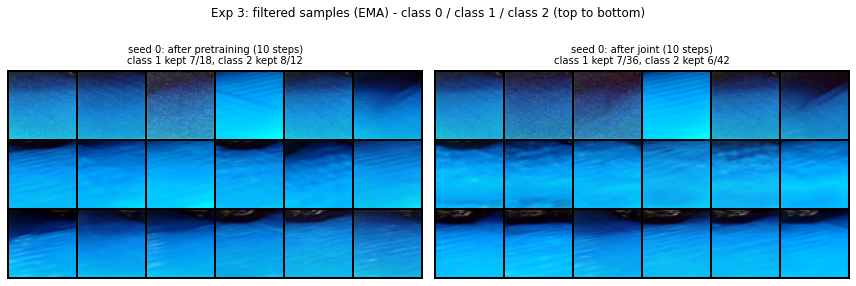

: 

In [44]:
if not joint_models:
    raise RuntimeError("이번 실행에서 학습한 모델이 없습니다. RESUME=True라서 결과가 이미 있는 seed를 건너뛰었습니다. "
                       "다시 학습하려면 설정 셀에서 RESUME = False로 바꾸거나 결과 CSV를 옮겨 두고 다시 실행하세요.")
for seed_to_show, joint_model in joint_models.items():
    set_split(seed_to_show)
    qf_show = build_quality_filter()  # 학습 때와 같은 필터 (이 seed의 실제 train 이미지 기준)
    pre_ema = Unet(dim=32, channels=channels, num_classes=num_classes).to(DEVICE)
    pre_ema.load_state_dict(torch.load(PRETRAINED_EMA_PATH.format(seed=seed_to_show), map_location=DEVICE))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, (name, model) in zip(axes, [("after pretraining", pre_ema), ("after joint", joint_model)]):
        x_vis, stats = sample_filtered_rows(model, qf_show)   # 두 모델 모두 같은 초기 노이즈(고정 seed)
        ax.imshow(make_grid(denorm(x_vis).clamp(0, 1), nrow=6).permute(1, 2, 0))
        ax.axis("off")
        ax.set_title(f"seed {seed_to_show}: {name} ({FILL_STEPS} steps)\n" + ", ".join(f"class {c} kept {k}/{g}" for c, (k, g) in stats.items()), fontsize=10)
    plt.suptitle("Exp 4: filtered samples (EMA) - class 0 / class 1 / class 2 (top to bottom)")
    plt.tight_layout()
    out_dir = f"exp4_images/exp4_images_seed{seed_to_show}"
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(f"{out_dir}/final_compare.png", dpi=110)
    plt.show()
